# Step 6 — Generative Sequential Retrieval (Decoder-Only Transformer)

Steps 1-5 built up to this: baselines that can't say anything about items they haven't seen
(Step 4), and Semantic IDs that give every item a content-derived identity even with zero
interaction history (Step 5). This notebook loads the trained model from
`backend/scripts/train_transformer.py` and walks through the math and the mechanics: how a
user's history becomes a token sequence, how the Transformer is built and trained, how
constrained beam search turns generated tokens back into real items, and what it actually
achieves, measured.

Full writeup: `docs/06_generative_retrieval.md`.

In [1]:
import os
import sys
import json
import pickle
from collections import Counter

sys.path.insert(0, os.path.abspath(os.path.join("..", "backend")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from models import transformer as tx

PROCESSED_DIR = os.path.join("..", "data", "processed")
pd.set_option("display.max_colwidth", 80)

## Tokenizing item histories

Every item's 4-digit Semantic ID (3 content codes + 1 dedup digit, from Step 5) is flattened
into 4 tokens in one shared vocabulary. Each level gets its own disjoint offset range so a
single embedding table covers everything:

$$
\text{token}(l_1, l_2, l_3, d) = \big[\, l_1,\;\; 256+l_2,\;\; 512+l_3,\;\; 768+d \,\big]
$$

with $l_1, l_2, l_3 \in \{0,\dots,255\}$ (one of 256 codes per RQ-VAE level) and
$d \in \{0,\dots,20\}$ (the dedup digit, capped at the observed maximum). Token 789 is PAD.
Total vocabulary size $|V| = 3\times256 + 21 + 1 = 790$.

A user's history becomes one long token stream:
$\big[\text{item}_1^{(1)}, \text{item}_1^{(2)}, \text{item}_1^{(3)}, \text{item}_1^{(4)},\;
\text{item}_2^{(1)}, \dots\big]$ -- exactly the shape a decoder-only Transformer expects, the
same way a language model consumes a stream of word tokens.

In [2]:
with open(os.path.join(PROCESSED_DIR, "transformer_vocab_meta.json")) as f:
    meta = json.load(f)
print(meta)

item_tokens = pd.read_parquet(os.path.join(PROCESSED_DIR, "item_tokens.parquet"))
item_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "item_catalog.parquet")).set_index("item_id")

example = item_tokens.iloc[0]
print(f"\nitem {example.item_id} ('{item_catalog.loc[example.item_id, 'description']}')"
      f" -> tokens [{example.tok1}, {example.tok2}, {example.tok3}, {example.tok4}]")

{'vocab_size': 790, 'pad_token': 789, 'level_size': 256, 'n_levels': 3, 'dedup_vocab': 21, 'max_items': 10, 'max_len': 40}

item 0 ('Wonder') -> tokens [117, 266, 630, 768]


## The architecture

Hand-rolled in plain JAX (`backend/models/transformer.py`) -- a GPT-2-style decoder-only
Transformer, pre-norm blocks. Every equation below is code you can point to directly, not a
library call.

**Embedding.** Token $t$ at sequence position $i$ becomes:
$$x_i = E[t] + P[i], \qquad E \in \mathbb{R}^{|V|\times d}, \;\; P \in \mathbb{R}^{T_{\max}\times d}$$

**LayerNorm.**
$$\mathrm{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

**Causal multi-head self-attention.** For each head, scaled dot-product attention with an
additive mask $M$ that is $0$ where attention is allowed and $-\infty$ where it's blocked
(future positions, and PAD positions):
$$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$$
Heads are computed in parallel then concatenated and projected back to $d$ dimensions by
$W_O$. The causal part of $M$ is what makes this a *decoder*: position $i$ can attend to
positions $\le i$ only, never the future -- otherwise the model could "cheat" by looking at
the very token it's being trained to predict.

**Feed-forward.**
$$\mathrm{FFN}(x) = \mathrm{GELU}(xW_1+b_1)\,W_2 + b_2$$

**Block (pre-norm residual).**
$$x \leftarrow x + \mathrm{Attention}(\mathrm{LN}(x)), \qquad x \leftarrow x + \mathrm{FFN}(\mathrm{LN}(x))$$

**Output projection (weight tying).** Rather than a separate output matrix, the logits reuse
the input embedding table transposed -- a standard GPT trick that removes the two largest
matrices in a small model down to one:
$$\mathrm{logits} = \mathrm{LN}_f(x)\, E^\top$$

Small on purpose: 2 blocks, 4 heads, 64-dim embeddings, 128-dim feed-forward.

In [3]:
D_MODEL, N_HEADS, N_LAYERS, D_FF = 64, 4, 2, 128

with open(os.path.join(PROCESSED_DIR, "transformer_checkpoint.pkl"), "rb") as f:
    ckpt = pickle.load(f)

params = jax.tree_util.tree_map(jnp.array, ckpt["params"])
n_params = sum(int(np.prod(p.shape)) for p in jax.tree_util.tree_leaves(params))
print(f"checkpoint at epoch {ckpt['epoch']}, {n_params:,} parameters")

checkpoint at epoch 10, 119,680 parameters


## Training objective

Standard causal language-modeling loss: predict token $t+1$ from everything before it,
negative log-likelihood, averaged only over real (non-PAD) target positions $\mathcal{T}$:

$$
\mathcal{L} = -\frac{1}{|\mathcal{T}|} \sum_{t \in \mathcal{T}} \log p_\theta\big(x_{t+1} \mid x_{\le t}\big)
$$

Trained one epoch at a time (each epoch is ~110-150s of compute -- see
`docs/06_generative_retrieval.md` for why this had to be resumable rather than one long run).
Loss dropped from $\ln(790) \approx 6.67$ (uniform random guessing over the vocabulary) to
2.76 after 10 epochs, still descending:

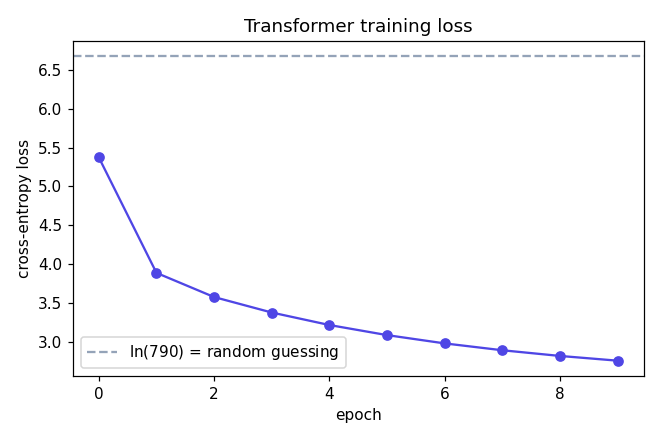

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ckpt["history"], marker="o", color="#4F46E5")
ax.axhline(np.log(790), color="#94A3B8", linestyle="--", label=r"$\ln(790)$ = random guessing")
ax.set_title("Transformer training loss")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss")
ax.legend()
plt.tight_layout()
plt.show()

## Constrained decoding: generation that's always a real item

The model's raw output at each of the 4 token positions is a probability distribution over
that level's codes -- but not every 4-token combination corresponds to a real catalog item.
The fix: a **trie** built directly from every real item's Semantic ID, mapping
$l_1 \to l_2 \to l_3 \to \{d: \text{item\_id}\}$. Generation only ever considers tokens that
keep the path inside the trie.

**Beam search.** Maintain the top $B$ partial sequences by cumulative log-probability at each
step, restricted to trie-valid tokens:

$$
\mathrm{score}(y_1,\dots,y_k) = \sum_{i=1}^{k} \log p_\theta\big(y_i \mid x,\, y_{<i}\big),
\qquad y_i \in \mathrm{ValidTokens}(\mathrm{trie}, y_{<i})
$$

After all 4 steps, every surviving beam maps to exactly one genuine item -- nothing needs to
be filtered out afterward, because invalid paths were never explored in the first place.

In [5]:
def build_trie(item_tokens):
    trie = {}
    for row in item_tokens.itertuples(index=False):
        trie.setdefault(row.tok1, {}).setdefault(row.tok2, {}).setdefault(row.tok3, {})[row.tok4] = row.item_id
    return trie

trie = build_trie(item_tokens)
print(f"trie built over {len(item_tokens):,} items")
print(f"level-1 branches actually used: {len(trie)} / 256")

trie built over 25,612 items
level-1 branches actually used: 73 / 256


## A worked example

Take a real user's most recent purchases as context, generate the top-10 next-item
predictions via constrained beam search, and check what they actually bought next.

In [6]:
sys.path.insert(0, os.path.abspath(os.path.join("..", "backend", "scripts")))
import evaluate_retrieval as ev

_, meta2, checkpoint_epoch, trie2, get_context, val_targets, test_targets = ev.setup()

rng = np.random.RandomState(7)
eligible = [u for u in val_targets if get_context(u) is not None]
sample_users = list(rng.choice(eligible, size=30, replace=False))
contexts = [get_context(u) for u in sample_users]
ranked_lists = ev.beam_search_batch(params, contexts, meta2, trie2)

seq = pd.read_parquet(os.path.join(PROCESSED_DIR, "train_sequences.parquet")).set_index("user_id")

for u, ranked in zip(sample_users, ranked_lists):
    top10 = [item_id for item_id, _ in ranked[:10]]
    hits = set(top10) & val_targets[u]
    if hits:
        print(f"user {u} -- recent history:")
        for it in seq.loc[u, "item_ids"][-4:]:
            print("  -", item_catalog.loc[it, "description"])
        print("top-10 predicted:")
        for it in top10:
            marker = "  <-- matches what they bought next" if it in val_targets[u] else ""
            print("  -", item_catalog.loc[it, "description"], marker)
        break

loaded checkpoint at epoch 10, last loss 2.7614
user 20582 -- recent history:
  - TechKen Wireless Controller Compatible for Nintendo Switch and Switch Lite All Version, Bluetooth Controller Support Rumble Gyro Axis Function Capture
  - YOOWA 3 in 1 Nintendo Switch Dockable Case - [Newest Version] Clear Protective Cover Case for Nintendo Switch and Joy-Con Controllers w/8 Thumb Grips Caps and Nintendo Switch Screen Protector - Clear
  - ButterFox Large Case Stand for Nintendo Switch, Fits Charger, Built-in Stand, 18 Game and 2 Micro SD Card Holders, Large Pouch for Nintendo Switch Console and Accessories
  - FastSnail Controller Charger Compatible with Nintendo Switch & OLED Model for Joycon, Charging Dock Station for Joy con and for Pro Controller with Charger Indicator and Type C Charging Cable
top-10 predicted:
  - amFilm Tempered Glass Screen Protector for Nintendo Switch 2017 (2-Pack)   <-- matches what they bought next
  - Nintendo Switch Pro Controller 
  - The Legend of Zelda: 

## Evaluation

Same Recall@K / NDCG@K as the Step 4 baselines, on a 2,000-user random sample per split
(full beam search over all ~55K val+test users wasn't tractable in this sandbox's time
budget -- see docs for the reasoning). Loading the saved results rather than re-running the
full evaluation live, since it's already been computed and takes ~65-70s per split:

In [7]:
with open(os.path.join(PROCESSED_DIR, "transformer_eval_results.json")) as f:
    eval_results = json.load(f)

baseline_results = json.load(open(os.path.join(PROCESSED_DIR, "baseline_results.json")))

rows = []
for split in ["val", "test"]:
    for model_name in ["popularity", "als"]:
        rows.append({"split": split, "model": model_name, **baseline_results[split][model_name]})
    rows.append({"split": split, "model": "transformer", **eval_results["results"][split]})

comparison_df = pd.DataFrame(rows).set_index(["split", "model"])
comparison_df.round(4)

recall@10  recall@20  ndcg@10  ndcg@20
split model                                              
val   popularity      0.0146     0.0180   0.0111   0.0122
      als             0.0149     0.0227   0.0107   0.0132
      transformer     0.0188     0.0259   0.0121   0.0142
test  popularity      0.0058     0.0071   0.0038   0.0042
      als             0.0051     0.0078   0.0036   0.0044
      transformer     0.0040     0.0064   0.0025   0.0032

A genuinely mixed result, reported honestly rather than only showing the flattering
half: the Transformer beats both baselines on every val metric at just 10 epochs of training,
but falls behind on test. Possible explanations -- test's higher cold-start rate (28.5% vs.
val's 18.3%) reshaping which users are "warm," under-training (loss was still descending),
or the 10-item context window losing signal for longer histories -- are open questions worth
more training time to resolve, not something to paper over. Full discussion in
`docs/06_generative_retrieval.md`.

## What's next

Step 7 (ranking) takes the top-N candidates this Transformer retrieves and reorders them
using features retrieval couldn't afford to compute for the whole catalog -- price, recency,
popularity, content similarity. Retrieval's job was narrowing the catalog down cheaply;
ranking's job is getting precise about the shortlist.